#### read data

In [63]:
import pandas as pd

df = pd.read_csv("DataSet/noisy_df.csv")
df

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,...,noise_91,noise_92,noise_93,noise_94,noise_95,noise_96,noise_97,noise_98,noise_99,price
0,7420,4,2,3,2,1.0,0.0,0.0,0.0,1.0,...,0.968645,-0.702053,-0.327662,-0.392108,-1.463515,0.296120,0.261055,0.005113,-0.234587,13300000
1,8960,4,4,4,3,1.0,0.0,0.0,0.0,1.0,...,0.856399,0.214094,-1.245739,0.173181,0.385317,-0.883857,0.153725,0.058209,-1.142970,12250000
2,9960,3,2,2,2,1.0,0.0,1.0,0.0,0.0,...,-0.493001,-0.589365,0.849602,0.357015,-0.692910,0.899600,0.307300,0.812862,0.629629,12250000
3,7500,4,2,2,3,1.0,0.0,1.0,0.0,1.0,...,0.491919,-1.320233,1.831459,1.179440,-0.469176,-1.713135,1.353872,-0.114540,1.237816,12215000
4,7420,4,1,2,2,1.0,1.0,1.0,0.0,1.0,...,1.479944,0.077368,-0.861284,1.523124,0.538910,-1.037246,-0.190339,-0.875618,-1.382800,11410000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,1.0,0.0,1.0,0.0,0.0,...,-0.328652,-1.921180,0.316163,-0.213023,-0.175872,0.740002,-0.283755,2.806700,0.808528,1820000
541,2400,3,1,1,0,0.0,0.0,0.0,0.0,0.0,...,-0.676898,1.285149,0.909561,0.039832,0.223066,1.036306,0.661869,0.261482,-0.450238,1767150
542,3620,2,1,1,0,1.0,0.0,0.0,0.0,0.0,...,-0.244761,0.073804,-0.643076,0.321994,1.827646,-0.166725,-0.681664,0.306680,-0.795086,1750000
543,2910,3,1,1,0,0.0,0.0,0.0,0.0,0.0,...,-0.330982,0.809636,0.039601,1.533121,-0.150160,1.882975,2.062682,0.458044,0.418275,1750000


#### Separate features and target

In [64]:
X = df.drop(columns=["price"])
y = df["price"]

#### Standardize the Features

In [65]:
from sklearn.preprocessing import StandardScaler

# Standardize (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.04672629,  1.40341936,  1.42181174, ...,  0.20691095,
        -0.01913772, -0.20286119],
       [ 1.75700953,  1.40341936,  5.40580863, ...,  0.10033019,
         0.03517975, -1.13169524],
       [ 2.21823241,  0.04727831,  1.42181174, ...,  0.25283231,
         0.80720462,  0.68081132],
       ...,
       [-0.70592066, -1.30886273, -0.57018671, ..., -0.72922649,
         0.28937105, -0.77597933],
       [-1.03338891,  0.04727831, -0.57018671, ...,  1.99595819,
         0.44421918,  0.46469928],
       [-0.5998394 ,  0.04727831, -0.57018671, ...,  0.33197592,
         0.30400034,  1.04050387]])

#### Apply PCA

In [66]:
from sklearn.decomposition import PCA

# Fit PCA
# pca = PCA(0.95)

# or 
pca = PCA(n_components=20)

X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_var = pca.explained_variance_ratio_
X_pca.shape

(545, 20)

#### Cumulative variance

In [67]:
import numpy as np
cumulative_var = np.cumsum(explained_var)
cumulative_var

array([0.02478319, 0.04267491, 0.06004273, 0.0770977 , 0.09391062,
       0.11032411, 0.12662341, 0.14282266, 0.15833984, 0.17359476,
       0.18862561, 0.20333292, 0.21754926, 0.23153158, 0.24544312,
       0.25929876, 0.27245443, 0.28544346, 0.29833677, 0.31092025])

#### Plot PCA variance

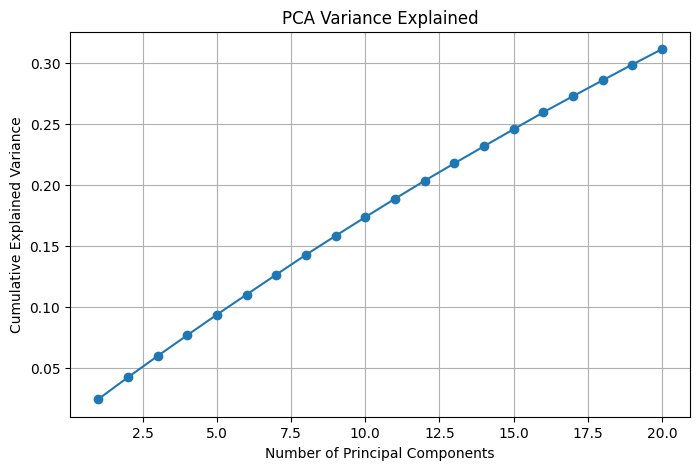

In [68]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained")
plt.grid(True)
plt.show()

#### Train-Test Split

In [69]:
from sklearn.model_selection import train_test_split

# Split the PCA-transformed data
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

#### Train SVM Regressor

In [70]:
from sklearn.svm import SVR

# Initialize SVM regressor
#svm_model = SVR(kernel='rbf', C=100, gamma=0.1)
svm_model = SVR(kernel='rbf')

# Train
svm_model.fit(X_train, y_train)


SVR()

#### Evaluate on Train and Test Sets

In [71]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict on training set
y_train_pred = svm_model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Predict on test set
y_test_pred = svm_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Report
print(f"🔧 Train MSE: {train_mse:.2f}")
print(f"🔧 Train R²: {train_r2:.2f}")
print(f"🧪 Test MSE: {test_mse:.2f}")
print(f"🧪 Test R²: {test_r2:.2f}")


🔧 Train MSE: 3256041064070.88
🔧 Train R²: -0.06
🧪 Test MSE: 5567983667612.61
🧪 Test R²: -0.10
